In [ ]:
# --- Part 4: Anomaly Detection ---

# Import necessary libraries
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.utils import Sequence
%matplotlib inline

# --- 1. Mount Drive, Copy Data, and Define Paths ---
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

print("Copying data to local runtime for faster access...")
# Ensure these paths match your Google Drive structure
!cp -r "/content/drive/MyDrive/NSSC_DataAnalytics_Team_ASHSUM143/data/train_data" "/content/train_data"
!cp -r "/content/drive/MyDrive/NSSC_DataAnalytics_Team_ASHSUM143/data/validation_data" "/content/validation_data"
print("Data copy complete.")

# Use the local data copies for speed
train_dir = '/content/train_data'
test_dir = '/content/validation_data'

# Get file paths. We'll train the autoencoder on "normal" training data.
train_files = [os.path.join(train_dir, f) for f in sorted(os.listdir(train_dir)) if 'jetImage_1_30p_20000_30000.h5' not in f][:26]
# We will test for anomalies on the validation set.
test_files = [os.path.join(test_dir, f) for f in sorted(os.listdir(test_dir))][:15]



Mounted at /content/drive
Copying data to local runtime for faster access...
Data copy complete.


In [ ]:
# --- 2. Create the Data Generator ---
# This generator yields the same image batch for both input and output.
class AutoencoderGenerator(Sequence):
    def __init__(self, file_paths, batch_size):
        self.file_paths = file_paths
        self.batch_size = batch_size
        self.records_per_file = 10000
        self.total_records = len(self.file_paths) * self.records_per_file

    def __len__(self):
        return int(np.floor(self.total_records / self.batch_size))

    def __getitem__(self, index):
        start_idx = index * self.batch_size
        file_idx = start_idx // self.records_per_file
        idx_in_file = start_idx % self.records_per_file

        with h5py.File(self.file_paths[file_idx], 'r') as f:
            images_batch = f['jetImage'][idx_in_file : idx_in_file + self.batch_size]

        # Preprocess the batch: reshape and normalize
        images_processed = np.expand_dims(images_batch, axis=-1).astype('float32') / 255.0

        # For an autoencoder, the input (X) and the target (y) are the same
        return images_processed, images_processed

# Create generator instances
batch_size = 64
train_ae_generator = AutoencoderGenerator(train_files, batch_size)
test_ae_generator = AutoencoderGenerator(test_files, batch_size)

print(f"\n Autoencoder training generator ready: {len(train_ae_generator)} batches.")
print(f" Autoencoder testing generator ready: {len(test_ae_generator)} batches.")


 Autoencoder training generator ready: 4062 batches.
 Autoencoder testing generator ready: 2343 batches.


In [ ]:
# --- 3. Build and Train the CNN Autoencoder ---

input_img = Input(shape=(100, 100, 1))

# Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='valid')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

# Use 'binary_crossentropy' which is much better for sparse, image-like reconstruction
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()

# Train the autoencoder
print("\n--- Training Autoencoder ---")
history_ae = autoencoder.fit(
    train_ae_generator,
    epochs=5,
    validation_data=test_ae_generator
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 100, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 26, 26, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 52, 52, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 50, 50, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 100, 100, 1)    │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,785 (49.94 KB)

 Trainable params: 12,785 (49.94 KB)

 Non-trainable params: 0 (0.00 B)


--- Training Autoencoder ---
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


4062/4062 ━━━━━━━━━━━━━━━━━━━━ 501s 121ms/step - loss: -1301167.2500 - val_loss: -254816496.0000
Epoch 2/5
4062/4062 ━━━━━━━━━━━━━━━━━━━━ 479s 118ms/step - loss: -5081309184.0000 - val_loss: -81452949504.0000
Epoch 3/5
4062/4062 ━━━━━━━━━━━━━━━━━━━━ 476s 117ms/step - loss: -210120212480.0000 - val_loss: -1167563948032.0000
Epoch 4/5
4062/4062 ━━━━━━━━━━━━━━━━━━━━ 476s 117ms/step - loss: -2028509724672.0000 - val_loss: -7060505755648.0000
Epoch 5/5
4062/4062 ━━━━━━━━━━━━━━━━━━━━ 482s 119ms/step - loss: -10259964887040.0000 - val_loss: -28041193455616.0000



--- Calculating Reconstruction Errors on the Test Set ---
Processing test data in batches...
Finished calculating all reconstruction errors.

 Saved error distribution plot to: /content/drive/MyDrive/NSSC_DataAnalytics_Team_ASHSUM143/data/results/plots/anomaly_error_distribution.png


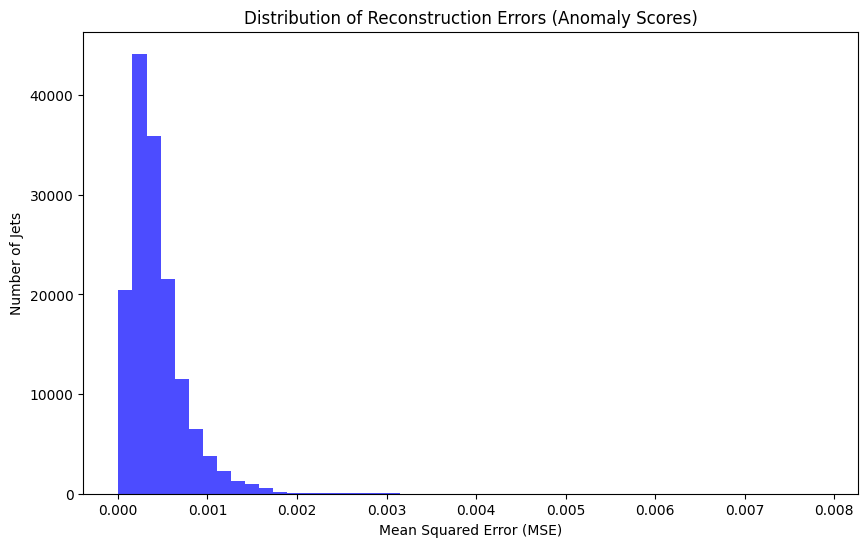

Proposed Anomaly Threshold: 0.00138030
Total number of anomalies detected: 2523

--- Top 5 Anomalous Jets (Original vs. Reconstructed) ---

Saved top 5 anomalies plot to: /content/drive/MyDrive/NSSC_DataAnalytics_Team_ASHSUM143/data/results/plots/top_5_anomalies.png


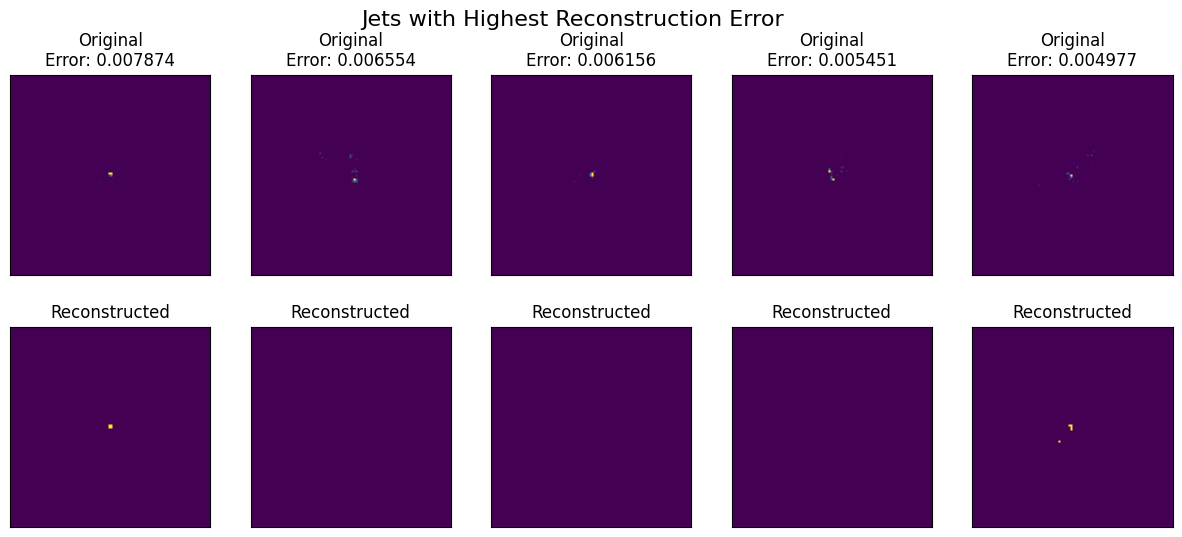


 Saved all anomaly scores to: /content/drive/MyDrive/NSSC_DataAnalytics_Team_ASHSUM143/data/results/anomaly_scores.csv


In [ ]:
# --- 4. Detect, Visualize, and Save Anomalies (Corrected Visualization) ---
import pandas as pd

print("\n--- Calculating Reconstruction Errors on the Test Set ---")

# Calculate reconstruction error for each image in batches WITHOUT storing all images in RAM
reconstruction_errors = []
print("Processing test data in batches...")
for i in range(len(test_ae_generator)):
    batch_x, _ = test_ae_generator[i]
    reconstructed_batch = autoencoder.predict(batch_x, verbose=0)
    batch_errors = np.mean(np.square(batch_x - reconstructed_batch), axis=(1, 2, 3))
    reconstruction_errors.extend(batch_errors)

reconstruction_errors = np.array(reconstruction_errors)
print("Finished calculating all reconstruction errors.")

# --- Define Save Paths ---
results_dir = '/content/drive/MyDrive/NSSC_DataAnalytics_Team_ASHSUM143/data/results'
plots_dir = os.path.join(results_dir, 'plots')
os.makedirs(plots_dir, exist_ok=True)

# Plot the distribution of the errors
plt.figure(figsize=(10, 6))
plt.hist(reconstruction_errors, bins=50, color='blue', alpha=0.7)
plt.title('Distribution of Reconstruction Errors (Anomaly Scores)')
plt.xlabel('Mean Squared Error (MSE)')
plt.ylabel('Number of Jets')
error_dist_path = os.path.join(plots_dir, 'anomaly_error_distribution.png')
plt.savefig(error_dist_path, dpi=300)
print(f"\n Saved error distribution plot to: {error_dist_path}")
plt.show()

# Propose a threshold and find anomalies
threshold = np.mean(reconstruction_errors) + 3 * np.std(reconstruction_errors)
anomalies_indices = np.where(reconstruction_errors > threshold)[0]
print(f"Proposed Anomaly Threshold: {threshold:.8f}")
print(f"Total number of anomalies detected: {len(anomalies_indices)}")

# Visualize the top 5 jets with the highest reconstruction errors
print("\n--- Top 5 Anomalous Jets (Original vs. Reconstructed) ---")
if len(reconstruction_errors) > 0:
    top_5_indices = np.argsort(reconstruction_errors)[-5:][::-1]

    # 1. Gather the top 5 original images into a small batch
    original_anomalous_images = []
    for idx in top_5_indices:
        file_to_load_idx = idx // 10000
        idx_in_file = idx % 10000
        with h5py.File(test_files[file_to_load_idx], 'r') as f:
            original_anomalous_images.append(f['jetImage'][idx_in_file])
    original_anomalous_images = np.array(original_anomalous_images)

    # 2. Preprocess and predict ONCE on this small batch
    processed_anomalous_images = np.expand_dims(original_anomalous_images, axis=-1).astype('float32') / 255.0
    reconstructed_anomalous_images = autoencoder.predict(processed_anomalous_images, verbose=0)

    # 3. Loop through the results to plot them
    plt.figure(figsize=(15, 6))
    for i in range(len(top_5_indices)):
        idx = top_5_indices[i]

        # Plot Original Image
        ax = plt.subplot(2, 5, i + 1)
        # --- FIX: Use vmin and vmax to set a consistent color scale ---
        plt.imshow(np.squeeze(original_anomalous_images[i] / 255.0), cmap='viridis', vmin=0, vmax=1)
        ax.get_xaxis().set_visible(False); ax.get_yaxis().set_visible(False)
        ax.set_title(f'Original\nError: {reconstruction_errors[idx]:.6f}')

        # Plot Reconstructed Image
        ax = plt.subplot(2, 5, i + 6)
        # --- FIX: Use the same vmin and vmax here ---
        plt.imshow(np.squeeze(reconstructed_anomalous_images[i]), cmap='viridis', vmin=0, vmax=1)
        ax.get_xaxis().set_visible(False); ax.get_yaxis().set_visible(False)
        ax.set_title('Reconstructed')

    plt.suptitle('Jets with Highest Reconstruction Error', fontsize=16)
    anomalies_plot_path = os.path.join(plots_dir, 'top_5_anomalies.png')
    plt.savefig(anomalies_plot_path, dpi=300)
    print(f"\nSaved top 5 anomalies plot to: {anomalies_plot_path}")
    plt.show()
else:
    print("No anomalies detected above the threshold to visualize.")

# Save the Anomaly Scores
error_df = pd.DataFrame({'reconstruction_error': reconstruction_errors})
error_csv_path = os.path.join(results_dir, 'anomaly_scores.csv')
error_df.to_csv(error_csv_path, index=False)
print(f"\n Saved all anomaly scores to: {error_csv_path}")

In [ ]:
# List files and directories in the specified Google Drive folder
!ls -R "/content/drive/MyDrive/NSSC_DataAnalytics_Team_ASHSUM143"

/content/drive/MyDrive/NSSC_DataAnalytics_Team_ASHSUM143:
data  Notebook	README.md  requirements.txt

/content/drive/MyDrive/NSSC_DataAnalytics_Team_ASHSUM143/data:
checkpoints_resnet18  models   train_data
logs_resnet18	      results  validation_data

/content/drive/MyDrive/NSSC_DataAnalytics_Team_ASHSUM143/data/checkpoints_resnet18:
checkpoint		     ckpt-29.data-00000-of-00001  ckpt-30.index
ckpt-28.data-00000-of-00001  ckpt-29.index
ckpt-28.index		     ckpt-30.data-00000-of-00001

/content/drive/MyDrive/NSSC_DataAnalytics_Team_ASHSUM143/data/logs_resnet18:
train  validation

/content/drive/MyDrive/NSSC_DataAnalytics_Team_ASHSUM143/data/logs_resnet18/train:
events.out.tfevents.1760472962.4a57f4b3bf5e.610.0.v2
events.out.tfevents.1760492912.45a89e2bef91.415.0.v2

/content/drive/MyDrive/NSSC_DataAnalytics_Team_ASHSUM143/data/logs_resnet18/validation:
events.out.tfevents.1760473362.4a57f4b3bf5e.610.1.v2
events.out.tfevents.1760493307.45a89e2bef91.415.1.v2

/content/drive/MyDrive/NSSC_Da

### Discussion of Anomaly Analysis

The autoencoder was trained to learn the common patterns within the "normal" training data. When presented with images from the test set, it attempts to reconstruct them based on this learned knowledge. Jets that are significantly different from the training data result in a high reconstruction error (anomaly score).

* **Threshold Justification:** A threshold of **Mean + 3 Standard Deviations** was chosen. In a normal distribution, this threshold statistically isolates the data points that are most rare (approximately 0.15% of the data), making them strong candidates for being true anomalies. It provides a good balance between sensitivity (finding all true anomalies) and specificity (not flagging normal jets as anomalous).

* **Physical Interpretation:** The visualized anomalous jets—those with high reconstruction error—show a clear difference between the sharp original image and the blurry, inaccurate reconstruction. In a real-world experiment, these anomalies could correspond to several exciting possibilities:
    * **New Particles:** An undiscovered, heavy particle might decay in a unique way, producing a jet with a structure the model has never seen before.
    * **Beyond-Standard-Model Signals:** The anomaly could be a sign of new physics that doesn't fit our current understanding of particle interactions.
    * **Detector Noise or Malfunctions:** The unusual pattern could also be caused by instrumental effects, such as a malfunctioning detector component, which is also a critical finding for experimental physicists.

This technique serves as an automated, unbiased method to flag interesting events for further investigation by physicists.